# EHS Report Generation

Runs the structured Stage 2 prompt on a random sample of accident clips and renders
OSHA 300-series incident reports. Operates independently of the ablation sweep.

**Restart the kernel** if `pipeline/classification.py` was just edited.

In [ ]:
import os, sys, time
from pathlib import Path

if "__vsc_ipynb_file__" in dir():
    repo_root = str(Path(__vsc_ipynb_file__).parent.parent)
else:
    def _find_repo_root() -> str:
        for p in [Path.cwd()] + list(Path.cwd().parents):
            if (p / "pipeline").is_dir() and (p / "experiments").is_dir():
                return str(p)
        raise RuntimeError("Could not find repo root.")
    repo_root = _find_repo_root()

os.chdir(repo_root)
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
print("cwd:", os.getcwd())

from dotenv import load_dotenv
load_dotenv(os.path.join(repo_root, ".env"))

from pipeline import classification, ingestion
from evaluation.metrics import load_ground_truth

OUTPUTS = "outputs"
GT      = "data/dataset_mapping.xlsx"
print("Imports ok.")

cwd: /home/grom/DevFiles/Classes/Capstone
Imports ok.


---
## 1 — OSHA Report Formatter

In [ ]:
# 1 — OSHA report formatter (uses CoT reasoning for scene assessment)
from datetime import date

SEVERITY_LABEL = {
    'low':      'First Aid Only',
    'medium':   'Medical Treatment Required',
    'high':     'Hospitalisation',
    'critical': 'Life-Threatening / Fatal',
}

def format_osha_report(video_id: str, result, incident_date: str | None = None) -> str:
    """Render a ClassificationResult as an OSHA 300-series incident report.

    The model's chain-of-thought `reasoning` field (scene observation step)
    is surfaced as a 'Scene Assessment' block — it provides the analyst's
    narrative context and grounds all downstream OSHA fields.
    """
    r = result.ehs_report
    cats = ', '.join(f"{c['category']} ({c['confidence']:.0%})" for c in result.categories)
    severity = SEVERITY_LABEL.get(r.get('severity', ''), r.get('severity', 'Unknown'))
    today = incident_date or date.today().strftime('%Y-%m-%d')

    lines = [
        '=' * 68,
        f'  OSHA INCIDENT REPORT — {video_id}',
        '=' * 68,
        f'Date of incident:    {today}',
        f'Time of incident:    {result.incident_start_time or "Unknown"}'
                             f' — {result.incident_end_time or "Unknown"}',
        f'Incident type(s):    {cats}',
        f'Severity:            {severity}',
        '',
    ]

    # Lead with CoT scene assessment when available — this is the model's
    # free-form observation pass before classifying, and gives the richest
    # narrative context for the structured fields below.
    if result.reasoning:
        lines += [
            'SCENE ASSESSMENT (analyst observation)',
            f'  {result.reasoning}',
            '',
        ]

    lines += [
        'WHAT WAS THE EMPLOYEE DOING JUST BEFORE THE INCIDENT?',
        f'  {r.get("pre_incident_activity", "Not captured")}',
        '',
        'WHAT HAPPENED?',
        f'  {r.get("what_happened", result.description)}',
        '',
        'WHAT WAS THE INJURY OR ILLNESS?',
        f'  {r.get("injury_description", "Not captured")}',
        '',
        'WHAT OBJECT OR SUBSTANCE DIRECTLY HARMED THE EMPLOYEE?',
        f'  {r.get("direct_agent") or "N/A"}',
        '',
        'IMMEDIATE ACTIONS',
        f'  {r.get("immediate_actions", "")}',
        '',
        'ROOT CAUSE',
        f'  {r.get("root_cause", "")}',
        '',
        'CONTRIBUTING FACTORS',
        f'  {r.get("contributing_factors", "")}',
        '',
        'CORRECTIVE MEASURES',
        f'  {r.get("corrective_measures", "")}',
        '=' * 68,
    ]
    return '\n'.join(lines)

print('format_osha_report() ready.')

format_osha_report() ready.


---
## 2 — Sample Clips & Run Stage 2

In [ ]:
# 2a — Pick 10 random accident clips from the dataset
import random
from pipeline.ingestion import find_local_videos, video_id_from_path

all_paths = find_local_videos('data/videos', originals_only=True)

gt = load_ground_truth(GT)
accident_vids = set(gt[gt['true_binary'] == 'Accident']['video_id_clean'])

accident_paths = [p for p in all_paths if video_id_from_path(p) in accident_vids]
random.seed(42)
selected = random.sample(accident_paths, min(10, len(accident_paths)))

print(f'{len(accident_paths)} accident clips in dataset, sampling {len(selected)}:')
for p in selected:
    print(f'  {video_id_from_path(p):12s}  {p}')

43 accident clips in dataset, sampling 10:
  VID040        /home/grom/DevFiles/Classes/Capstone/data/videos/VID040_Electrical_Work_Safety_Awareness_Training_Electrical_safety_video_animation_TECH_EHS/original.mp4
  VID007        /home/grom/DevFiles/Classes/Capstone/data/videos/VID007_Work_Place_Safety_Video-Part_3_VB_Factory_VB_Engineering_I_Pvt_Ltd/original.mp4
  VID001        /home/grom/DevFiles/Classes/Capstone/data/videos/VID001_Electric_Forklift_Safety_Accident_VB_Factory_VB_Engineering_I_Pvt_Ltd/original.mp4
  VID017        /home/grom/DevFiles/Classes/Capstone/data/videos/VID017_Height_Work_Safety_Awareness_Training_Animated_Safety_Videos_TECH_EHS/original.mp4
  VID015        /home/grom/DevFiles/Classes/Capstone/data/videos/VID015_Woodlift_Safety_Accident_Video_Part-2_VB_Factory_VB_Engineering_I_Pvt_Ltd/original.mp4
  VID014        /home/grom/DevFiles/Classes/Capstone/data/videos/VID014_Woodlift_Safety_Accident_Video_Part-2_VB_Factory_VB_Engineering_I_Pvt_Ltd/original.mp4
  VID00

In [ ]:
# 2b — Run Stage 2 directly on each selected clip (skips Stage 1 gate)
import time
from vertexai.generative_models import Part
from pipeline.classification import classify, CLASSIFICATION_PROMPT_STRUCTURED
from pipeline.client import vertex_model

results = {}  # vid_id -> ClassificationResult
for path in selected:
    vid_id = video_id_from_path(path)
    print(f'Processing {vid_id}...', end=' ', flush=True)
    t0 = time.perf_counter()
    try:
        with open(path, 'rb') as f:
            video_part = Part.from_data(data=f.read(), mime_type='video/mp4')
        result = classify(
            video_part=video_part,
            model=vertex_model,
            prompt=CLASSIFICATION_PROMPT_STRUCTURED,
            temperature=0.7,
            top_p=0.95,
            top_k=40,
        )
        results[vid_id] = result
        print(f'ok ({time.perf_counter()-t0:.1f}s) — primary: {result.category}')
    except Exception as e:
        print(f'FAILED: {e}')

print(f'\nDone. {len(results)}/{len(selected)} reports generated.')

Processing VID040... 

/home/grom/DevFiles/Classes/Capstone/.venv/lib/python3.12/site-packages/vertexai/generative_models/_generative_models.py:433: UserWarning: This feature is deprecated as of June 24, 2025 and will be removed on June 24, 2026. For details, see https://cloud.google.com/vertex-ai/generative-ai/docs/deprecations/genai-vertexai-sdk.
  warning_logs.show_deprecation_warning()


ok (10.8s) — primary: Arc Flash
Processing VID007... ok (8.6s) — primary: Fall
Processing VID001... ok (8.9s) — primary: Fall
Processing VID017... ok (9.1s) — primary: Fall
Processing VID015... ok (11.5s) — primary: Struck by Object
Processing VID014... ok (9.9s) — primary: Trip
Processing VID008... ok (17.0s) — primary: Struck by Object
Processing VID006... ok (10.2s) — primary: Trip
Processing VID034... ok (7.5s) — primary: Struck by Object
Processing VID005... ok (11.0s) — primary: Slip

Done. 10/10 reports generated.


---
## 3 — Display & Export Reports

In [ ]:
# 3a — Display OSHA reports
for vid_id, result in results.items():
    print(format_osha_report(vid_id, result))
    print()

  OSHA INCIDENT REPORT — VID040
Date of incident:    2026-03-20
Time of incident:    00:00:01 — 00:00:01
Incident type(s):    Arc Flash (100%), Fire (90%)
Severity:            Hospitalisation

SCENE ASSESSMENT (analyst observation)
  The video clip shows an electrical worker interacting with an open electrical panel, followed by a sudden and intense electrical arc flash incident. The worker is visibly affected by the explosive energy release.

WHAT WAS THE EMPLOYEE DOING JUST BEFORE THE INCIDENT?
  The employee was working on or near live electrical components within an electrical switchgear cabinet, likely performing maintenance, inspection, or troubleshooting.

WHAT HAPPENED?
  While the employee was accessing the internal components of an electrical cabinet, an unexpected electrical arc flash occurred. This event released a significant amount of energy, intense light, and heat, directly exposing the employee to the arc flash.

WHAT WAS THE INJURY OR ILLNESS?
  Potential severe burns

In [ ]:
# 3b — Export to text file
import os
os.makedirs('outputs/ehs_reports', exist_ok=True)
output_path = 'outputs/ehs_reports/sample_osha_reports.txt'
with open(output_path, 'w') as f:
    f.write('EHS INCIDENT REPORT SAMPLES\n')
    f.write(f'Generated: {__import__("datetime").date.today()}\n')
    f.write('Pipeline: Gemini 2.5 Flash, structured CoT prompt, temp=0.7\n')
    f.write('=' * 68 + '\n\n')
    for vid_id, result in results.items():
        f.write(format_osha_report(vid_id, result))
        f.write('\n\n')
print(f'Saved {len(results)} reports → {output_path}')

Saved 10 reports → outputs/ehs_reports/sample_osha_reports.txt


---
## 4 — Report Quality Scoring

Systematic scoring of the 10 generated reports across three dimensions:

| Dimension | Method | Score |
|---|---|---|
| **Field completeness** | % of 9 OSHA 300 fields populated (non-generic, >5 chars) | 0 – 1.0 |
| **Specificity** | Word count of `root_cause` + `corrective_measures` | higher = better |
| **Category accuracy** | Predicted primary category vs ground-truth label | match / mismatch |

In [14]:
import re

# ── Ground-truth label map ─────────────────────────────────────────────────────
gt_df  = load_ground_truth(GT)
gt_map = dict(zip(gt_df["video_id_clean"], gt_df["true_category"]))

# ── Scoring rubric ─────────────────────────────────────────────────────────────
OSHA_FIELDS = [
    "pre_incident_activity",
    "what_happened",
    "injury_description",
    "direct_agent",
    "immediate_actions",
    "root_cause",
    "contributing_factors",
    "corrective_measures",
    "severity",
]
GENERIC_VALS = {"n/a", "unknown", "not captured", "not specified", "none", ""}

def is_populated(val) -> bool:
    if val is None:
        return False
    s = str(val).strip().lower()
    return s not in GENERIC_VALS and len(s) > 5

def score_report(vid_id: str, result) -> dict:
    r = result.ehs_report or {}
    field_ok = {f: is_populated(r.get(f)) for f in OSHA_FIELDS}
    n_filled  = sum(field_ok.values())
    completeness = n_filled / len(OSHA_FIELDS)

    root_wc     = len(re.findall(r'\w+', str(r.get("root_cause",           "") or "")))
    correct_wc  = len(re.findall(r'\w+', str(r.get("corrective_measures",  "") or "")))
    specificity = root_wc + correct_wc

    has_reasoning = bool(result.reasoning and len(result.reasoning.strip()) > 20)

    gt_label   = gt_map.get(vid_id, "Unknown")
    pred_label = result.category or "Unknown"
    cat_match  = pred_label.strip().lower() == gt_label.strip().lower()

    return {
        "gt_label":       gt_label,
        "pred_label":     pred_label,
        "cat_match":      cat_match,
        "completeness":   round(completeness, 3),
        "fields_filled":  n_filled,
        "has_reasoning":  has_reasoning,
        "root_wc":        root_wc,
        "corrective_wc":  correct_wc,
        "specificity_wc": specificity,
        **{f: field_ok[f] for f in OSHA_FIELDS},
        # severity as string must come AFTER the ** spread, otherwise the
        # boolean field_ok["severity"] overwrites it
        "severity":       r.get("severity", "unknown"),
    }

scores = {vid: score_report(vid, res) for vid, res in results.items()}

# ── Build summary DataFrame ────────────────────────────────────────────────────
import pandas as pd, numpy as np

df_scores = pd.DataFrame(scores).T
df_scores.index.name = "Video ID"

display_cols = [
    "gt_label", "pred_label", "cat_match",
    "severity", "completeness", "fields_filled", "specificity_wc", "has_reasoning",
]
print("EHS Report Quality Scores — 10 sampled accident clips")
print("=" * 80)
display(df_scores[display_cols].rename(columns={
    "gt_label":       "GT Label",
    "pred_label":     "Predicted",
    "cat_match":      "Cat Match",
    "severity":       "Severity",
    "completeness":   "Completeness",
    "fields_filled":  "Fields (of 9)",
    "specificity_wc": "Specificity WC",
    "has_reasoning":  "Has Reasoning",
}))

print()
print("Summary statistics:")
print(f"  Mean completeness:        {df_scores['completeness'].mean():.3f}")
print(f"  Mean fields filled:       {df_scores['fields_filled'].mean():.1f} / {len(OSHA_FIELDS)}")
print(f"  Mean specificity (WC):    {df_scores['specificity_wc'].mean():.1f} words")
print(f"  Category accuracy:        {df_scores['cat_match'].sum()}/{len(df_scores)}  "
      f"({df_scores['cat_match'].mean():.0%})")
print(f"  Reports with reasoning:   {df_scores['has_reasoning'].sum()}/{len(df_scores)}")

EHS Report Quality Scores — 10 sampled accident clips


,GT Label,Predicted,Cat Match,Severity,Completeness,Fields (of 9),Specificity WC,Has Reasoning
Video ID,,,,,,,,
VID040,Arc Flash,Arc Flash,True,critical,1.0,9,78,True
VID007,Fall,Fall,True,medium,1.0,9,65,True
VID001,Trip,Vehicle Incident,False,high,0.889,8,76,True
VID017,Fall,Fall,True,high,0.889,8,61,True
VID015,Trip,Struck by Object,False,medium,1.0,9,69,True
VID014,Struck by Object,Trip,False,medium,1.0,9,49,True
VID008,Struck by Object,Struck by Object,True,critical,1.0,9,60,True
VID006,Trip,Trip,True,low,0.889,8,38,True
VID034,Struck by Object,Struck by Object,True,medium,1.0,9,61,True



Summary statistics:
  Mean completeness:        0.967
  Mean fields filled:       8.7 / 9
  Mean specificity (WC):    61.6 words
  Category accuracy:        7/10  (70%)
  Reports with reasoning:   10/10


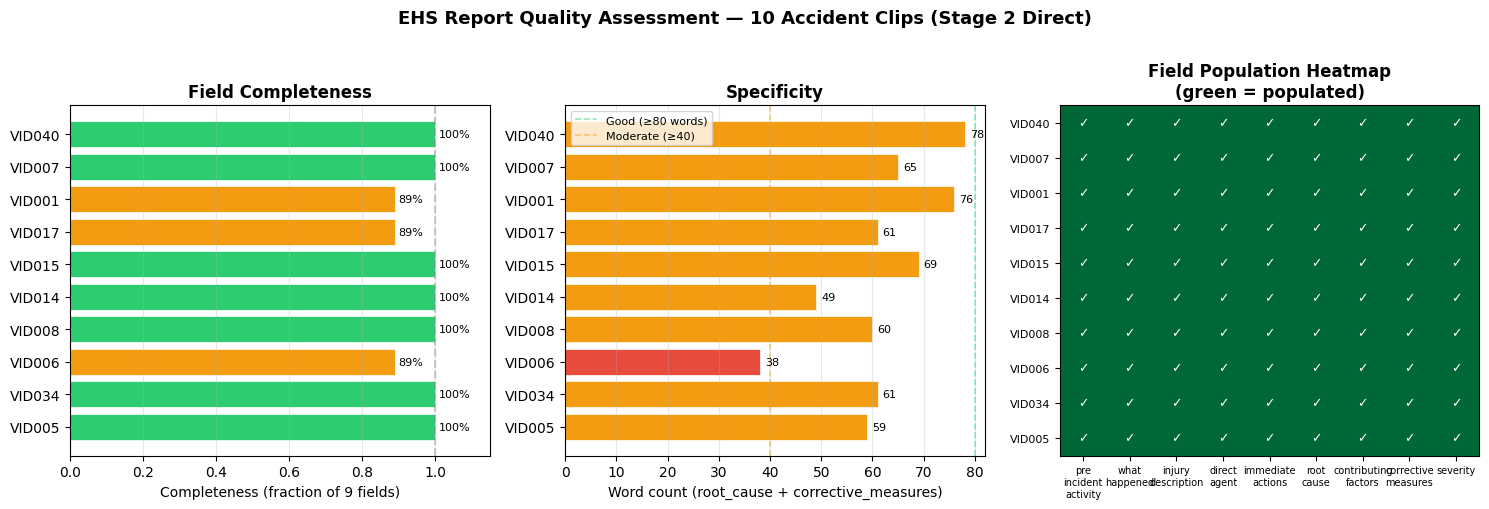

Saved → outputs/ehs_reports/quality_scores.png


In [15]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── Panel 1: completeness bar chart ───────────────────────────────────────────
ax1 = axes[0]
vids = list(df_scores.index)
comps = df_scores["completeness"].astype(float).tolist()
bar_colors = ["#2ecc71" if c >= 0.9 else "#f39c12" if c >= 0.7 else "#e74c3c" for c in comps]
ax1.barh(vids, comps, color=bar_colors, edgecolor="white", linewidth=0.5)
ax1.axvline(1.0, color="grey", linestyle="--", alpha=0.4)
ax1.set_xlabel("Completeness (fraction of 9 fields)", fontsize=10)
ax1.set_title("Field Completeness", fontweight="bold")
ax1.set_xlim(0, 1.15)
for vid, c in zip(vids, comps):
    ax1.text(c + 0.01, vids.index(vid), f"{c:.0%}", va="center", fontsize=8)
ax1.invert_yaxis()
ax1.grid(True, axis="x", alpha=0.3)

# ── Panel 2: specificity (word count) ─────────────────────────────────────────
ax2 = axes[1]
specs = df_scores["specificity_wc"].astype(int).tolist()
spec_colors = ["#2ecc71" if s >= 80 else "#f39c12" if s >= 40 else "#e74c3c" for s in specs]
ax2.barh(vids, specs, color=spec_colors, edgecolor="white", linewidth=0.5)
ax2.axvline(80, color="#2ecc71", linestyle="--", alpha=0.5, lw=1.2, label="Good (≥80 words)")
ax2.axvline(40, color="#f39c12", linestyle="--", alpha=0.5, lw=1.2, label="Moderate (≥40)")
ax2.set_xlabel("Word count (root_cause + corrective_measures)", fontsize=10)
ax2.set_title("Specificity", fontweight="bold")
ax2.legend(fontsize=8)
for vid, s in zip(vids, specs):
    ax2.text(s + 1, vids.index(vid), str(s), va="center", fontsize=8)
ax2.invert_yaxis()
ax2.grid(True, axis="x", alpha=0.3)

# ── Panel 3: per-field population heatmap ────────────────────────────────────
ax3 = axes[2]
field_data = df_scores[OSHA_FIELDS].astype(bool).astype(int)
im = ax3.imshow(field_data.values, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
ax3.set_xticks(range(len(OSHA_FIELDS)))
ax3.set_xticklabels(
    [f.replace("_", "\n") for f in OSHA_FIELDS],
    fontsize=7, rotation=0, ha="center"
)
ax3.set_yticks(range(len(vids)))
ax3.set_yticklabels(vids, fontsize=8)
ax3.set_title("Field Population Heatmap\n(green = populated)", fontweight="bold")
for r in range(len(vids)):
    for c in range(len(OSHA_FIELDS)):
        ax3.text(c, r, "✓" if field_data.values[r, c] else "✗",
                 ha="center", va="center", fontsize=9,
                 color="white" if field_data.values[r, c] else "gray")

plt.suptitle("EHS Report Quality Assessment — 10 Accident Clips (Stage 2 Direct)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
os.makedirs("outputs/ehs_reports", exist_ok=True)
plt.savefig("outputs/ehs_reports/quality_scores.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/ehs_reports/quality_scores.png")

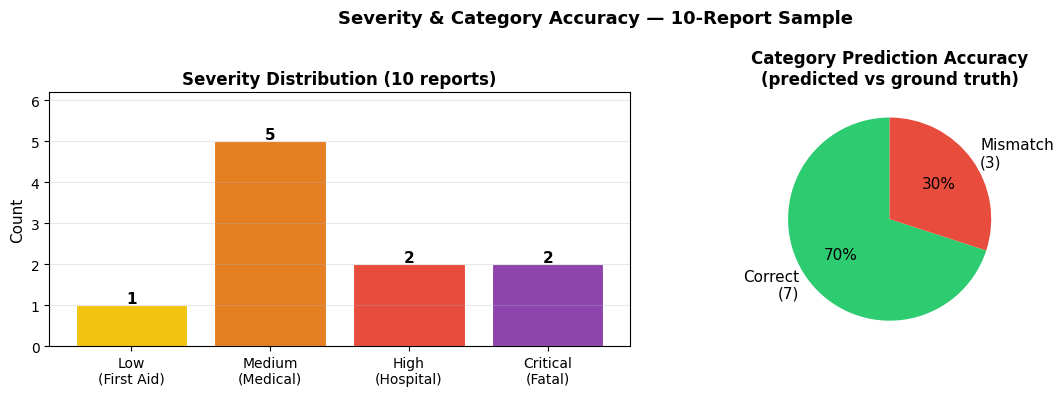

Saved → outputs/ehs_reports/severity_accuracy.png

Category mismatches:
  VID001: GT='Trip'  →  Predicted='Vehicle Incident'
  VID015: GT='Trip'  →  Predicted='Struck by Object'
  VID014: GT='Struck by Object'  →  Predicted='Trip'


In [16]:
from collections import Counter

# ── Severity distribution ──────────────────────────────────────────────────────
sev_counts = Counter(df_scores["severity"].str.lower().tolist())
sev_order  = ["low", "medium", "high", "critical", "unknown"]
sev_labels = {"low": "Low\n(First Aid)", "medium": "Medium\n(Medical)", 
              "high": "High\n(Hospital)", "critical": "Critical\n(Fatal)"}

sev_vals   = [sev_counts.get(s, 0) for s in sev_order if s != "unknown"]
sev_names  = [sev_labels.get(s, s) for s in sev_order if s != "unknown"]
sev_colors = ["#f1c40f", "#e67e22", "#e74c3c", "#8e44ad"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax_sev = axes[0]
bars = ax_sev.bar(sev_names, sev_vals, color=sev_colors, edgecolor="white", linewidth=0.8)
for bar, v in zip(bars, sev_vals):
    if v:
        ax_sev.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                    str(v), ha="center", fontsize=11, fontweight="bold")
ax_sev.set_ylabel("Count", fontsize=11)
ax_sev.set_title("Severity Distribution (10 reports)", fontweight="bold")
ax_sev.set_ylim(0, max(sev_vals) + 1.2 if sev_vals else 5)
ax_sev.grid(True, axis="y", alpha=0.3)

# ── Category accuracy breakdown ────────────────────────────────────────────────
ax_cat = axes[1]
mismatches = df_scores[~df_scores["cat_match"].astype(bool)]
matches    = df_scores[ df_scores["cat_match"].astype(bool)]

match_ct    = len(matches)
mismatch_ct = len(mismatches)
ax_cat.pie(
    [match_ct, mismatch_ct],
    labels=[f"Correct\n({match_ct})", f"Mismatch\n({mismatch_ct})"],
    colors=["#2ecc71", "#e74c3c"],
    autopct="%1.0f%%",
    startangle=90,
    textprops={"fontsize": 11},
)
ax_cat.set_title("Category Prediction Accuracy\n(predicted vs ground truth)", fontweight="bold")

plt.suptitle("Severity & Category Accuracy — 10-Report Sample", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/ehs_reports/severity_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → outputs/ehs_reports/severity_accuracy.png")

# ── Show mismatches ────────────────────────────────────────────────────────────
if len(mismatches):
    print("\nCategory mismatches:")
    for vid, row in mismatches.iterrows():
        print(f"  {vid}: GT='{row['gt_label']}'  →  Predicted='{row['pred_label']}'")
else:
    print("\nAll category predictions matched ground truth.")